In [21]:
import wandb
import pandas as pd
from datetime import datetime, timezone

wandb.login()
api = wandb.Api()

# === CONFIGURATION ===
project_path = "tidiane/patch_icl_eval"
timestamp_str_start = "2026-03-20T00:00:00Z"
timestamp_str_end = "2026-03-21T00:00:00Z"
dataset = "totalseg"

# Filter options (applied before computing dice)
EXCLUDE_VERTEBRAE = True  # Set to True to exclude vertebrae from analysis
EXCLUDE_RIBS = False       # Set to True to exclude ribs from analysis
EXCLUDE_CUSTOM = []        # Add custom label patterns to exclude, e.g. ['kidney_cyst']

print(f"Dataset: {dataset}")
print(f"Filters: vertebrae={EXCLUDE_VERTEBRAE}, ribs={EXCLUDE_RIBS}, custom={EXCLUDE_CUSTOM}")

# Fetch runs
run_filters = {
    "$and": [
        {"created_at": {"$gt": timestamp_str_start, "$lt": timestamp_str_end}},
        {"config.base_dataset": dataset},
    ]
}

filtered_runs = api.runs(
    path=project_path,
    filters=run_filters
)

runs_data = {}

# Iterate through runs and extract metrics + per-case dice
for run in filtered_runs:
    print(f"Processing run: {run.name} (ID: {run.id})")
    
    try:
        # FIX: Reload full run data to get config (filtered query doesn't populate it)
        full_run = api.run(f"{project_path}/runs/{run.id}")
        config = full_run.config
        print(f"  config: {config}")
        
        method = config.get("method")
        input_size = config.get("preprocessing", {}).get("image_size", {})
        context_size_config = config.get("context_size")
        
        # Handle context_size being int or dict
        if isinstance(context_size_config, int):
            context_size = context_size_config
        else:
            context_size = context_size_config.get("val", {}) if context_size_config else None

        # Try to download per-case dice artifact
        per_case_df = None
        try:
            artifact = api.artifact(f"tidiane/patch_icl_eval/run-{run.id}-per_case_dice:v0")
            artifact.download()
            table = artifact.get("per_case_dice.table.json")
            per_case_df = table.get_dataframe()
        except Exception as e:
            print(f"  -> No per_case_dice artifact: {e}")


        

        runs_data[run.name] = {
            "wandb_id": run.id,
            "config": config,
            "method": method,
            "input_size": input_size,
            "context_size": context_size,
            "gflops_per_sample": full_run.summary.get("gflops_per_sample"), 
            "val_final_dice": full_run.summary.get("val_final_dice"),
            "per_case_df": per_case_df,
        }
    except Exception as e:
        print(f"  -> Error processing run {run.name}: {e}")

print(f"\nSuccessfully downloaded data for {len(runs_data)} runs.")

Dataset: totalseg
Filters: vertebrae=True, ribs=False, custom=[]
Processing run: sparkling-energy-378 (ID: op2xk0du)
  config: {'model': {'patch_icl': {'loss': {'weights': {'default': {'target_patch': 1, 'context_patch': 0.5, 'target_aggreg': 1, 'context_aggreg': 0.5}, 'target_patch': 0, 'context_patch': 0, 'target_aggreg': 0, 'context_aggreg': 0, 'target_combined': 1}, 'confidence': {'method': 'entropy', 'enabled': True, 'weighted_seg': False, 'boundary_width': 2, 'boundary_weight': 0, 'supervision_weight': 0}, 'patch_loss': {'args': None, 'type': 'softdiceFocal'}, 'aggreg_loss': {'args': None, 'type': 'softdiceFocal'}, 'level_weights': [0, 0, 0, 1]}, 'levels': [{'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 24, 'num_patches': 9, 'sampling_method': 'continuous', 'num_context_patches': 9, 'sampling_temperature': 0.1}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 64, 'num_patches': 20, 'sampling_method': 'continuous', 'num_

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Processing run: solar-grass-381 (ID: fggn0eg8)
  config: {'model': {'patch_icl': {'loss': {'weights': {'default': {'target_patch': 1, 'context_patch': 0.5, 'target_aggreg': 1, 'context_aggreg': 0.5}, 'target_patch': 0, 'context_patch': 0, 'target_aggreg': 0, 'context_aggreg': 0, 'target_combined': 1}, 'confidence': {'method': 'entropy', 'enabled': True, 'weighted_seg': False, 'boundary_width': 2, 'boundary_weight': 0, 'supervision_weight': 0}, 'patch_loss': {'args': None, 'type': 'softdiceFocal'}, 'aggreg_loss': {'args': None, 'type': 'softdiceFocal'}, 'level_weights': [0, 0, 0, 1]}, 'levels': [{'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 24, 'num_patches': 9, 'sampling_method': 'continuous', 'num_context_patches': 9, 'sampling_temperature': 0.1}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 64, 'num_patches': 20, 'sampling_method': 'continuous', 'num_context_patches': 20, 'spread_sigma_target': 4, 'sampling_temperature'

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Processing run: breezy-wave-384 (ID: wvrc9wnc)
  config: {'loss': {'aggreg_loss': {'args': None, 'type': 'softdice'}}, 'model': {'patch_icl': {'loss': {'weights': {'target_patch': 0, 'context_patch': 0, 'target_aggreg': 0, 'context_aggreg': 0, 'target_combined': 1}, 'patch_loss': {'args': None, 'type': 'softdiceFocal'}, 'aggreg_loss': {'args': None, 'type': 'softdiceFocal'}, 'level_weights': [0, 0, 0, 1]}, 'levels': [{'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 24, 'num_patches': 9, 'sampling_method': 'continuous', 'num_context_patches': 9, 'sampling_temperature': 0.1}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 64, 'num_patches': 20, 'sampling_method': 'continuous', 'num_context_patches': 20, 'spread_sigma_target': 4, 'sampling_temperature': 0.1, 'spread_sigma_context': 4}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 128, 'num_patches': 20, 'sampling_method': 'continuous', 'num_contex

...

Processing run: resilient-jazz-400 (ID: iy68zdig)
  config: {'model': {'patch_icl': {'loss': {'weights': {'default': {'target_patch': 1, 'context_patch': 0.5, 'target_aggreg': 1, 'context_aggreg': 0.5}, 'target_patch': 0, 'context_patch': 0, 'target_aggreg': 0, 'context_aggreg': 0, 'target_combined': 1}, 'confidence': {'method': 'entropy', 'enabled': True, 'weighted_seg': False, 'boundary_width': 2, 'boundary_weight': 0, 'supervision_weight': 0}, 'patch_loss': {'args': None, 'type': 'softdiceFocal'}, 'aggreg_loss': {'args': None, 'type': 'softdiceFocal'}, 'level_weights': [0, 0, 0, 1]}, 'levels': [{'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 24, 'num_patches': 9, 'sampling_method': 'continuous', 'num_context_patches': 9, 'sampling_temperature': 0.1}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 64, 'num_patches': 20, 'sampling_method': 'continuous', 'num_context_patches': 20, 'spread_sigma_target': 4, 'sampling_temperatu

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Processing run: tough-plant-401 (ID: 49cpvclc)
  config: {'loss': {'aggreg_loss': {'args': None, 'type': 'softdice'}}, 'model': {'patch_icl': {'loss': {'weights': {'target_patch': 0, 'context_patch': 0, 'target_aggreg': 0, 'context_aggreg': 0, 'target_combined': 1}, 'patch_loss': {'args': None, 'type': 'softdiceFocal'}, 'aggreg_loss': {'args': None, 'type': 'softdiceFocal'}, 'level_weights': [0, 0, 0, 1]}, 'levels': [{'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 24, 'num_patches': 9, 'sampling_method': 'continuous', 'num_context_patches': 9, 'sampling_temperature': 0.1}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 64, 'num_patches': 20, 'sampling_method': 'continuous', 'num_context_patches': 20, 'spread_sigma_target': 4, 'sampling_temperature': 0.1, 'spread_sigma_context': 4}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 128, 'num_patches': 30, 'sampling_method': 'continuous', 'num_contex

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  



Successfully downloaded data for 16 runs.


In [22]:
print(method)

universeg


In [23]:
# Apply filters and recompute dice scores
excluded_patterns = []
if EXCLUDE_VERTEBRAE:
    excluded_patterns.append('vertebrae')
if EXCLUDE_RIBS:
    excluded_patterns.append('rib_')
excluded_patterns.extend(EXCLUDE_CUSTOM)

def compute_filtered_dice(per_case_df, excluded_patterns):
    """Compute mean dice after excluding specified label patterns."""
    if per_case_df is None:
        return None
    
    df = per_case_df.copy()
    
    if excluded_patterns:
        pattern = '|'.join(excluded_patterns)
        mask = df['label_id'].astype(str).str.contains(pattern, case=False, regex=True)
        n_excluded = mask.sum()
        df = df[~mask]
        
    return df['dice'].mean() if len(df) > 0 else None

# Recompute dice with filters applied
print("=" * 60)
if excluded_patterns:
    print(f"APPLYING FILTER: Excluding patterns {excluded_patterns}")
else:
    print("NO FILTER APPLIED")
print("=" * 60)

for run_name, data in runs_data.items():
    original_dice = data['val_final_dice']
    filtered_dice = compute_filtered_dice(data['per_case_df'], excluded_patterns)
    
    # Use filtered dice if available, otherwise fall back to original
    if filtered_dice is not None:
        data['filtered_dice'] = filtered_dice
        if excluded_patterns and original_dice is not None:
            diff = filtered_dice - original_dice
            print(f"{run_name}: {original_dice:.4f} -> {filtered_dice:.4f} (Δ={diff:+.4f})")
        else:
            data['filtered_dice'] = filtered_dice
    else:
        data['filtered_dice'] = original_dice  # Fallback to original if no per-case data

print(f"\nDice scores {'recomputed with filters' if excluded_patterns else 'unchanged'}.")

APPLYING FILTER: Excluding patterns ['vertebrae']
celestial-cosmos-380: 0.2405 -> 0.2358 (Δ=-0.0047)
vocal-eon-383: 0.5769 -> 0.5642 (Δ=-0.0127)
breezy-wave-384: 0.6840 -> 0.6566 (Δ=-0.0274)
silvery-sound-385: 0.4936 -> 0.4863 (Δ=-0.0074)
fiery-feather-386: 0.4953 -> 0.4835 (Δ=-0.0119)
stellar-cherry-388: 0.4420 -> 0.4167 (Δ=-0.0253)
winter-fog-389: 0.5274 -> 0.5174 (Δ=-0.0100)
hearty-feather-390: 0.4582 -> 0.3974 (Δ=-0.0609)
jumping-pine-396: 0.4072 -> 0.4018 (Δ=-0.0055)
amber-night-399: 0.4471 -> 0.3849 (Δ=-0.0621)
resilient-jazz-400: 0.4123 -> 0.3807 (Δ=-0.0315)
tough-plant-401: 0.3918 -> 0.3524 (Δ=-0.0394)

Dice scores recomputed with filters.


In [24]:
# Display run summary
print("=" * 70)
print("RUN SUMMARY")
print("=" * 70)
print(f"\n{'Run':<25} {'Method':<12} {'Ctx':<5} {'Size':<5} {'GFLOPs':<10} {'Dice':<8}")
print("-" * 70)

for run_name, data in runs_data.items():
    print(data["method"], data["context_size"], data["input_size"], data["gflops_per_sample"], data["filtered_dice"])
    method = data['method'] or 'N/A'
    ctx = data['context_size'] if not isinstance(data['context_size'], list) else 'var'
    size = data['input_size'] or 'N/A'
    gflops = f"{data['gflops_per_sample']:.1f}" if data['gflops_per_sample'] else 'N/A'
    dice = f"{data['filtered_dice']:.4f}" if data['filtered_dice'] else 'N/A'
    
    #print(f"{run_name:<25} {method:<12} {ctx:<5} {size:<5} {gflops:<10} {dice:<8}")

RUN SUMMARY

Run                       Method       Ctx   Size  GFLOPs     Dice    
----------------------------------------------------------------------
patch_icl [1, 3, 6] 256 None None
patch_icl 1 256 None None
patch_icl 1 256 61.914601727199994 0.23576134866955434
patch_icl 15 256 None None
patch_icl 10 256 289.0533953236 0.5641636060444725
universeg 10 256 428.003557376 0.6565836844892873
patch_icl 6 128 102.5838309092 0.4862523836189554
patch_icl 6 128 83.78480695792 0.4834621355831993
patch_icl 6 512 None None
patch_icl 3 256 112.3137201136 0.4166548084991649
patch_icl 6 512 548.635945656 0.5174324912535326
universeg 3 256 137.338290176 0.3973616797116892
patch_icl 3 512 307.5431547888 0.4017572898022258
universeg 3 512 549.353160704 0.38492776317514604
patch_icl 3 128 51.5258854048 0.38073791870419876
universeg 3 128 34.334572544 0.35243830880630034


In [25]:
# Find cases where patch_icl is good and universeg is bad
# Fix context_size=3 and compare across same input_size

# Build a flat df with columns: label_id, dice, method, input_size
records = []
for run_name, data in runs_data.items():
    if data['per_case_df'] is None:
        continue
    df_tmp = data['per_case_df'].copy()
    df_tmp['method'] = data['method']
    df_tmp['input_size'] = data['input_size']
    df_tmp['context_size'] = data['context_size']
    records.append(df_tmp)

df_all = pd.concat(records, ignore_index=True)
print(df_all.columns.tolist())
print(df_all.head())
print(f"\nMethods: {df_all['method'].unique()}")
print(f"Input sizes: {df_all['input_size'].unique()}")


['case_id', 'label_id', 'axis', 'dice', 'method', 'input_size', 'context_size']
  case_id           label_id axis      dice     method  input_size  \
0   s0000  iliac_artery_left  N/A  0.431579  patch_icl         256   
1   s0000  iliac_artery_left  N/A  0.669510  patch_icl         256   
2   s0000  iliac_artery_left  N/A  0.577855  patch_icl         256   
3   s0000  iliac_artery_left  N/A  0.554128  patch_icl         256   
4   s0000  iliac_artery_left  N/A  0.181818  patch_icl         256   

   context_size  
0             1  
1             1  
2             1  
3             1  
4             1  

Methods: ['patch_icl' 'universeg']
Input sizes: [256 128 512]


In [26]:
# Compare patch_icl vs universeg at the same input_size, ctx=3
# Pivot to get one row per (label_id, input_size) with dice for each method
INPUT_SIZE = 128  # change to 256 or 512 to compare at different scales

df_cmp = df_all[df_all['input_size'] == INPUT_SIZE].copy()
pivot = df_cmp.groupby(['label_id', 'method'])['dice'].mean().unstack('method')
pivot = pivot.dropna(subset=['patch_icl', 'universeg'])
pivot['delta'] = pivot['patch_icl'] - pivot['universeg']  # positive = patch_icl wins

# Cases where patch_icl >> universeg
threshold = 0.05
good_patch = pivot[pivot['delta'] > threshold].sort_values('delta', ascending=False)
print(f"Cases where patch_icl > universeg by >{threshold} (input_size={INPUT_SIZE}):")
print(good_patch.to_string())


Cases where patch_icl > universeg by >0.05 (input_size=128):
method                        patch_icl  universeg     delta
label_id                                                    
kidney_cyst_right              0.683087   0.387696  0.295391
atrial_appendage_left          0.568656   0.314100  0.254556
rib_left_9                     0.446901   0.212302  0.234599
femur_right                    0.628837   0.395761  0.233076
rib_left_8                     0.423780   0.225274  0.198507
prostate                       0.676024   0.482096  0.193928
rib_right_7                    0.432318   0.241166  0.191153
rib_left_7                     0.429931   0.241690  0.188241
liver                          0.553929   0.371855  0.182074
rib_right_8                    0.406442   0.224589  0.181854
rib_right_9                    0.403476   0.227236  0.176240
vertebrae_T9                   0.523905   0.357820  0.166085
vertebrae_T8                   0.499049   0.334087  0.164962
vertebrae_T7            

Method: patch_icl, ctx values:
  ctx=3, GFLOPs=51.526, Dice=0.3807
  ctx=6, GFLOPs=83.785, Dice=0.4835
  ctx=6, GFLOPs=102.584, Dice=0.4863
Method: universeg, ctx values:
  ctx=3, GFLOPs=34.335, Dice=0.3524


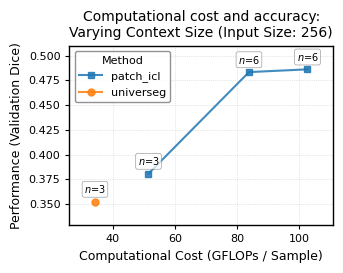

Method: patch_icl, in values:
  in=128, GFLOPs=51.526, Dice=0.3807
  in=256, GFLOPs=112.314, Dice=0.4167
  in=512, GFLOPs=307.543, Dice=0.4018
Method: universeg, in values:
  in=128, GFLOPs=34.335, Dice=0.3524
  in=256, GFLOPs=137.338, Dice=0.3974
  in=512, GFLOPs=549.353, Dice=0.3849


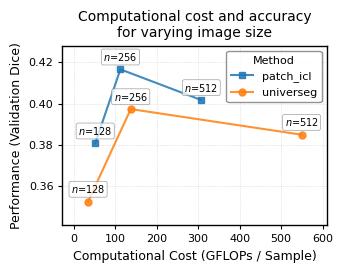

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Publication-ready style — sized for a single LaTeX column (~3.5 in)
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'legend.title_fontsize': 8,
    'figure.autolayout': True,
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
})

# Convert runs_data to DataFrame (using filtered_dice)
df = pd.DataFrame.from_dict(runs_data, orient='index')

# Use filtered_dice for plotting
dice_col = 'filtered_dice'


def plot_pareto(df, vary_col, fixed_col, fixed_val, title, filename, label_prefix):
    fig, ax = plt.subplots(figsize=(3.5, 2.8))

    # Filter for the specific experiment
    plot_df = df[df[fixed_col] == fixed_val].copy()

    # Remove rows with missing data
    plot_df = plot_df.dropna(subset=['gflops_per_sample', dice_col])

    if plot_df.empty:
        print(f"No data found for {fixed_col} == {fixed_val}. Skipping plot.")
        return

    methods = plot_df['method'].unique()
    colors  = {'universeg': 'tab:orange', 'patch_icl': 'tab:blue'}
    markers = {'universeg': 'o',          'patch_icl': 's'}

    for method in methods:
        method_df = plot_df[plot_df['method'] == method].sort_values('gflops_per_sample')

        ax.plot(
            method_df['gflops_per_sample'],
            method_df[dice_col],
            marker=markers.get(method, 'o'),
            color=colors.get(method, 'k'),
            label=method,
            alpha=0.85,
        )

        # Annotate each data point
        for _, row in method_df.iterrows():
            ax.annotate(
                f"$n$={int(row[vary_col])}",
                (row['gflops_per_sample'], row[dice_col]),
                textcoords="offset points",
                xytext=(0, 6),
                ha='center',
                fontsize=7,
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    fc="white",
                    ec="gray",
                    alpha=0.75,
                    lw=0.5,
                ),
            )

        # Print plotted values
        print(f"Method: {method}, {label_prefix} values:")
        for _, row in method_df.iterrows():
            print(
                f"  {label_prefix}={int(row[vary_col])}, "
                f"GFLOPs={row['gflops_per_sample']:.3f}, "
                f"Dice={row[dice_col]:.4f}"
            )

    ax.set_xlabel('Computational Cost (GFLOPs / Sample)')
    ax.set_ylabel('Performance (Validation Dice)')
    ax.set_title(title, pad=6)
    ax.legend(title="Method", framealpha=0.85, edgecolor='gray')
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.6)

    # Tight margins so the plot area fills the figure
    ax.margins(x=0.12, y=0.18)

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


# Plot for Varying Context Size (Fixing Input Size to 128)
plot_pareto(
    df,
    vary_col='context_size',
    fixed_col='input_size',
    fixed_val=128,
    title='Computational cost and accuracy:\nVarying Context Size (Input Size: 256)',
    filename='pareto_context_size.pdf',
    label_prefix='ctx',
)

# Plot for Varying Input Size (Fixing Context Size to 3)
plot_pareto(
    df,
    vary_col='input_size',
    fixed_col='context_size',
    fixed_val=3,
    title='Computational cost and accuracy\nfor varying image size',
    filename='pareto_input_size.pdf',
    label_prefix='in',
)